# Práctica 2 - Variables Aleatorias Continuas: Esperanza, Momentos y Varianza

**Licenciatura en Matemáticas Aplicadas, UAM-C**  
**UEA:** Probabilidad II  
**Trimestre:** 26P  
**Grupo:** CF01MA  
**Profesora** Daniela Aguirre Guerrero

---

## Objetivos

Al finalizar esta práctica, el alumnado será capaz de:

1. Calcular la **esperanza** $\mathbb{E}[X]$ de una variable aleatoria continua e interpretarla como centro de masa y como límite del promedio muestral.
2. Calcular la **varianza** y verificar la identidad $\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$.
4. Verificar **numéricamente** (integración y simulación Monte Carlo) los resultados analíticos.
5. Aplicar estos conceptos en la resolución de problemas.

---

## 1. Marco teórico

### 1.1 Esperanza

Sea $X$ una variable aleatoria continua con función de densidad $f_X$. La **esperanza** (o valor esperado, o media) de $X$ se define como
$$\mathbb{E}[X] =\mu_{X}= \int_{-\infty}^{\infty} x\, f_X(x)\, dx,$$

Dos interpretaciones equivalentes:

- **Estadística:** límite del promedio muestral $\bar X_n \to \mathbb{E}[X]$ (Ley de los Grandes Números).
- **Física:** centro de masa (punto de equilibrio) de la densidad.

### 1.2 Esperanza de una función de $X$

Para una función $g(x)$, tenemos que
$$\mathbb{E}[g(X)] = \int_{-\infty}^{\infty} g(x)\, f_X(x)\, dx.$$

No es necesario hallar la densidad de $Y=g(X)$; basta integrar contra $f_X$.

### 1.3 Varianza

La **varianza** describe la dispersión alrededor de la media:
$$\mathrm{Var}(X) = \mathbb{E}\big[(X-\mu)^2\big] \geq 0.$$

Cumple la siguiente identidad:
$$\boxed{\;\mathrm{Var}(X) = \mathbb{E}[X^2] - \big(\mathbb{E}[X]\big)^2\;}$$

## 2. Preparación del entorno

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

# Ajustes de visualización
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

np.random.seed(42)  # reproducibilidad

## 3. La esperanza como centro de masa

La esperanza $\mathbb{E}[X]$ es el punto donde la densidad queda "en equilibrio", igual que el centro de masa de una varilla cuya densidad lineal es $f_X(x)$.

Definimos una función auxiliar que calcula la esperanza integrando numéricamente $x\,f_X(x)$ y la dibuja sobre la densidad.

In [10]:
def esperanza_numerica(X, lo, hi):
    """Calcula E[X] = ∫ x f_X(x) dx (en los intervalos: lo - hi) por integración numérica."""
    valor, _ = integrate.quad(lambda x: x * X.pdf(x), lo, hi)
    return valor


def grafica_centro_masa(X, eje_x, mu, titulo):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    pdf_vals = X.pdf(eje_x)

    # Grafica f(x)
    ax.plot(eje_x, pdf_vals, color='C0', lw=2, label=r'$f_X(x)$') 

    # Línea vertical en la media (E[X])
    ax.axvline(mu, color='C3', lw=2.5, label=fr'$\mathbb{{E}}[X] = {mu:.4f}$')

    # Coloca titulo, leyendas, etc.
    ax.set_title(titulo)
    ax.set_xlabel('x'); ax.set_ylabel(r'$f_X(x)$')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

### 3.1 Ejemplo: tiempo de vida de una laptop

Modelamos la vida útil (en cientos de horas) de una laptop con una variable exponencial $$f_X(x) = \begin{cases} \lambda e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}, \qquad F_X(x) = \begin{cases} 1 - e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}$$

donde $\lambda = \frac{1}{100}$.  
Teóricamente, $\mathbb{E}[X] = 1/\lambda = 100$.

E[X] teórica   (1/λ)        = 100.000000
E[X] numérica  (∫ x f dx)   = 100.000000
E[X] de scipy  (X.mean())   = 100.000000


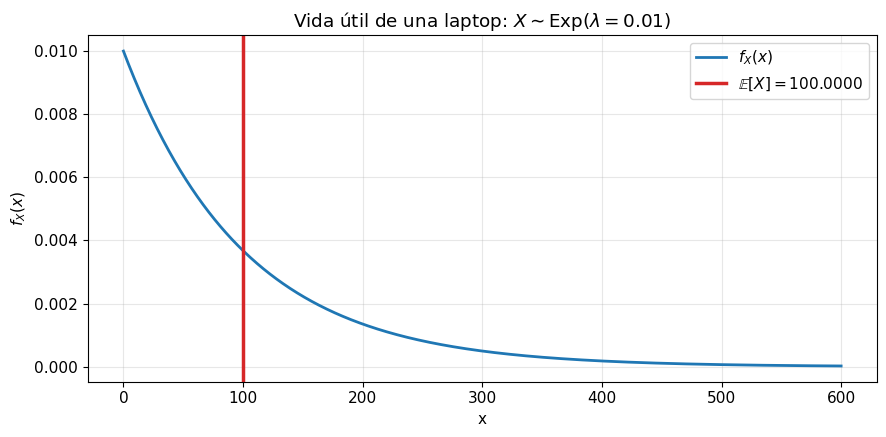

In [11]:
lam = 0.01
X = stats.expon(scale=1/lam)
eje_x = np.linspace(0, 600, 1000)

# Esperanza teórica 
mu_teorica = 1/lam
# Esperanza númerica (aproximada con scipy.integrate)
mu_numerica = esperanza_numerica(X, 0, np.inf)
# Esperanza como el promedio de un muchas observaciones de X
mu_media = X.mean()

print(f"E[X] teórica   (1/λ)        = {mu_teorica:.6f}")
print(f"E[X] numérica  (∫ x f dx)   = {mu_numerica:.6f}")
print(f"E[X] de scipy  (X.mean())   = {mu_media:.6f}")

grafica_centro_masa(X, eje_x, mu_numerica,
                    r'Vida útil de una laptop: $X \sim \mathrm{Exp}(\lambda=0.01)$')

Observa que la media (100) está **a la derecha** del grueso de la densidad: la cola larga arrastra el centro de equilibrio.

### 3.2 La esperanza como límite del promedio muestral

La Ley de los Grandes Números garantiza que el promedio de muchas observaciones de $X$ converge a $\mathbb{E}[X]$. Lo verificamos simulando.

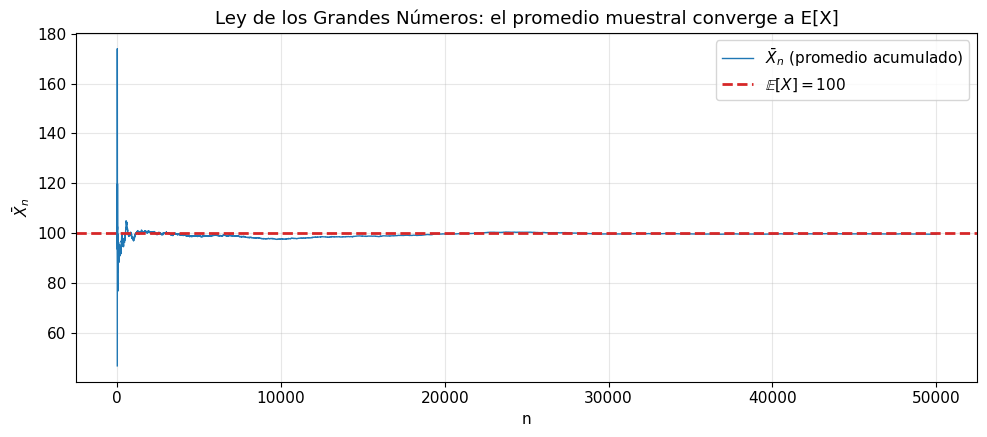

n =     10:  promedio = 102.6970
n =    100:  promedio = 91.4748
n =   1000:  promedio = 97.2506
n =  10000:  promedio = 97.7499
n =  50000:  promedio = 99.6117


In [12]:
n_max = 50000

# Tomamos desde n=1 hasta 50000 observaciones de X
# Cada muestra n tiene n observaciones de X
muestra = X.rvs(size=n_max)

# Calculamos el promedio de cada muestra
promedios = np.cumsum(muestra) / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(promedios, color='C0', lw=1, label=r'$\bar{X}_n$ (promedio acumulado)')
ax.axhline(mu_teorica, color='C3', lw=2, ls='--',
           label=fr'$\mathbb{{E}}[X] = {mu_teorica:.0f}$')
#ax.set_xscale('log')
#ax.set_xlabel('n (escala log)')
ax.set_xlabel('n')
ax.set_ylabel(r'$\bar{X}_n$')
ax.set_title('Ley de los Grandes Números: el promedio muestral converge a E[X]')
ax.legend()
plt.tight_layout()
plt.show()

for n in [10, 100, 1000, 10000, 50000]:
    print(f"n = {n:>6}:  promedio = {muestra[:n].mean():.4f}")

## 4. Varianza: la identidad fundamental

Verificamos numéricamente la identidad
$$\mathrm{Var}(X) =\sigma_X^2= \mathbb{E}[X^2] - \big(\mathbb{E}[X]\big)^2$$
de **dos maneras**: aproximando la integral con scipy.integrate y con la identidad.

In [15]:
def varianza_numerica(X, lo, hi, mu):
    g = lambda x: (x - mu)**2 * X.pdf(x)
    valor, _ = integrate.quad(g, lo, hi)
    return valor

In [16]:
def esperanza_x2(X, lo, hi):
    g = lambda x: x**2 * X.pdf(x)
    valor, _ = integrate.quad(g, lo, hi)
    return valor

In [19]:
# Forma 1: Numericamente, aproximando la integral
var_numerica = varianza_numerica(X, 0, np.inf, mu=mu_teorica)

# Forma 2: identidad E[X^2] - (E[X])^2 
mu_teorica = 1/lam
EX2 = esperanza_x2(X, 0, np.inf)
var_identidad = EX2 - mu_teorica**2

print(f"Var(X) por ∫ (x-μ)^2 f dx        = {var_numerica:.6f}")
print(f"Var(X) por E[X^2] - (E[X])^2     = {var_identidad:.6f}")
print(f"Var(X) teórica (1/λ²)            = {1/lam**2:.6f}")

Var(X) por ∫ (x-μ)^2 f dx        = 10000.000000
Var(X) por E[X^2] - (E[X])^2     = 10000.000000
Var(X) teórica (1/λ²)            = 10000.000000


### 4.1 Visualización: la desviación estándar como ancho

La desviación estándar $\sigma_X$ mide cuánto se aleja típicamente $X$ de su media. 
La dibujamos como una banda $\mu \pm \sigma$ sobre la densidad.

In [22]:
def grafica_media_sigma(X, eje_x, mu, sigma, titulo):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    pdf_vals = X.pdf(eje_x)
    ax.plot(eje_x, pdf_vals, color='C0', lw=2, label=r'$f_X(x)$')

    # Banda mu ± sigma
    mask = (eje_x >= mu - sigma) & (eje_x <= mu + sigma)
    ax.fill_between(eje_x[mask], pdf_vals[mask], alpha=0.3, color='C2',
                    label=fr'$\mu_X \pm \sigma_X = {mu:.1f} \pm {sigma:.1f}$')

    ax.axvline(mu, color='C3', lw=2.5, label=fr'$\mu_X = {mu:.2f}$')
    ax.axvline(mu - sigma, color='C2', lw=1.5, ls='--')
    ax.axvline(mu + sigma, color='C2', lw=1.5, ls='--')

    ax.set_title(titulo)
    ax.set_xlabel('x'); ax.set_ylabel(r'$f_X(x)$')
    ax.legend()
    plt.tight_layout()
    plt.show()

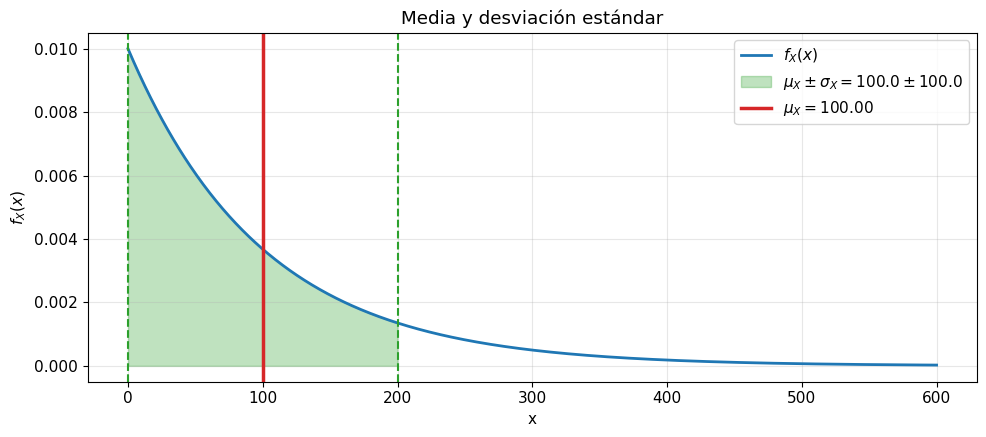

In [23]:
sigma = np.sqrt(var_numerica)
grafica_media_sigma(X, eje_x, mu_teorica, sigma,
                    r'Media y desviación estándar')

## 5. Ejercicios

Resuelve cada ejercicio en celdas nuevas, combinando código y celdas markdown con las deducciones a mano cuando se pida.

### Ejercicio 1 — Distribución uniforme

Sea $X \sim \mathcal{U}(2, 7)$.

1. Deduce analíticamente (a mano) que $\mathbb{E}[X] = \tfrac{a+b}{2}$ y $\mathrm{Var}(X) = \tfrac{(b-a)^2}{12}$.
2. Crea la distribución uniform con la función `stats.uniform` y calcula $\mathbb{E}[X]$ con la función `esperanza_numerica`.
3. Calcula $\mathrm{Var}(X)$ con la función `varianza_numerica` y con laidentidad $\mathbb{E}[X^2]-\mathbb{E}[X]^2$.
4. Usa ka función `grafica_media_sigma` para visualizar la esperanza y la desviación estándar.

### Ejercicio 2 — Distribución normal

Sea $X \sim \mathcal{N}(\mu=3,\ \sigma=1.5)$.

1. Calcula numéricamente la media y la varianza y compáralas con los parámetros.
2. Crea la variable con `stats.norm` y calcula $\mathbb{E}[X]$ con la función `esperanza_numerica`.
3. Calcula $\mathrm{Var}(X)$ con la función `varianza_numerica` y con laidentidad $\mathbb{E}[X^2]-\mathbb{E}[X]^2$.
4. Usa ka función `grafica_media_sigma` para visualizar la esperanza y la desviación estándar.

### Ejercicio 3 — Propiedades de la esperanza y la varianza

Sea $X \sim \mathrm{Exp}(\lambda=0.5)$ y define $Y = 3X + 2$.

1. Predice analíticamente $\mathbb{E}[Y]$ y $\mathrm{Var}(Y)$ usando $\mathbb{E}[aX+b]=a\mathbb{E}[X]+b$ y $\mathrm{Var}(aX+b)=a^2\mathrm{Var}(X)$.
2. Verifica tus predicciones con las funciones `esperanza_numerica` y `varianza_numerica`.
3. Comenta: ¿por qué la constante aditiva $b$ no afecta la varianza?